# Sunspots: Warp Regression on the Solar Cycle

The [Lynx notebook](LynxForecast.ipynb) and the [Bitcoin notebook](BitcoinWarp.ipynb) both ran warp regression on a few decades of data. This one pushes further: the monthly sunspot number, recorded continuously since 1749, is the longest series in this repo by a wide margin, and it comes with its own well known irregular cycle.

The sun's magnetic activity rises and falls on the ~11-year Schwabe cycle: sunspot counts climb to a maximum, decline to a minimum, and repeat. Astronomers have tracked this since Heinrich Schwabe first noticed it in 1843, and it has been the textbook example of a "regular but not that regular" cycle ever since. Individual cycles have run anywhere from about 9 to 14 years, amplitudes vary by a factor of three or four between cycles, and there is an ongoing scientific debate about how far ahead any of this can actually be forecast. A known approximate shape riding on a genuinely wandering period is exactly the kind of problem this repo is built for.

Same recipe as Lynx:

- **Two sine cycles sharing one warp path**: a slow one for the ~11-year Schwabe cycle, a faster one for the asymmetric rise-and-fall shape within each cycle.
- **Nonlinear observation models** (small MLPs) instead of a linear combination.
- **Raw monthly counts, no log transform**: the observation models can bend to the skew directly, same reasoning as the updated Lynx notebook.

**Split:** train on 1749-2010 (3144 months), test on 2011-2026 (186 months, spanning solar cycles 24 and most of 25). Steps 1-3 only ever see the training months; step 4 forecasts the held-out months and checks them against the actual monthly counts.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from warp_regression import (
    interval_coverage,
    per_index_rw_sigma,
    plot_before_after_warp,
    plot_dual_objective_scatter,
    plot_fit_with_residual,
    plot_forecast_bands,
    plot_warp_offset,
    prefit,
    prepare_sunspots,
    split_holdout_by_year,
)


## Step 1: load the data and get a rough pair of sines in place

Load the monthly series (SILSO's total sunspot number, 1749-present) and split at the end of 2010. Then, before any warping happens, fit two fixed-frequency sines $z_1(t)$ and $z_2(t)$ on calendar time: their sum is the **unwarped baseline**, what a naive "two cycles, fixed period" model would give you. Because the series is monthly rather than annual, the omega ranges below are chosen so the fitted periods land near 9-14 years ($z_1$, the Schwabe cycle itself) and 3-7 years ($z_2$, the asymmetric rise/decline shape within each cycle), rather than reusing Lynx's annual-scale defaults directly.


In [2]:
data = prepare_sunspots(transform="identity")
years, counts, t, y = data["years"], data["counts"], data["t"], data["y_log"]

split = split_holdout_by_year(data, train_end_year=2010.999)
train_idx, test_idx = split["train_idx"], split["test_idx"]
years_tr, years_te = split["years_train"], split["years_test"]
y_tr, y_te = y[train_idx], y[test_idx]
t_tr = t[train_idx]
n_train = split["n_train"]

print(f"Train: {int(years_tr[0])}-{int(years_tr[-1])} (n={n_train} months)")
print(f"Test:  {int(years_te[0])}-{int(years_te[-1])} (n={split['n_test']} months)")

# omega counts cycles across the whole normalized time axis, so with monthly
# samples we target periods in months, not years: 9-14 yr -> 108-168 months.
omega1_range = (n_train / 168, n_train / 108)
omega2_range = (n_train / 84, n_train / 36)

prefit_res = prefit(y_tr, t_tr, n_sines=2, years=years_tr, omega1_range=omega1_range, omega2_range=omega2_range)
fit = prefit_res.sine_fit
s1, s2 = fit["sine1"], fit["sine2"]
print(f"Sine 1: omega={s1['omega']:.3f}, period~{s1['period_years']/12:.1f} yr, a={s1['amplitude']:.3f}")
print(f"Sine 2: omega={s2['omega']:.3f}, period~{s2['period_years']/12:.1f} yr, peak_align={s2['peak_alignment']:.3f}")
print(f"R2(train)={fit['r2_log']:.3f}, RMSE(train)={fit['rmse_log']:.1f}")


Train: 1749-2010 (n=3144 months)
Test:  2011-2026 (n=186 months)


Sine 1: omega=25.212, period~11.0 yr, a=46.601
Sine 2: omega=47.825, period~5.8 yr, peak_align=0.532
R2(train)=0.237, RMSE(train)=59.8


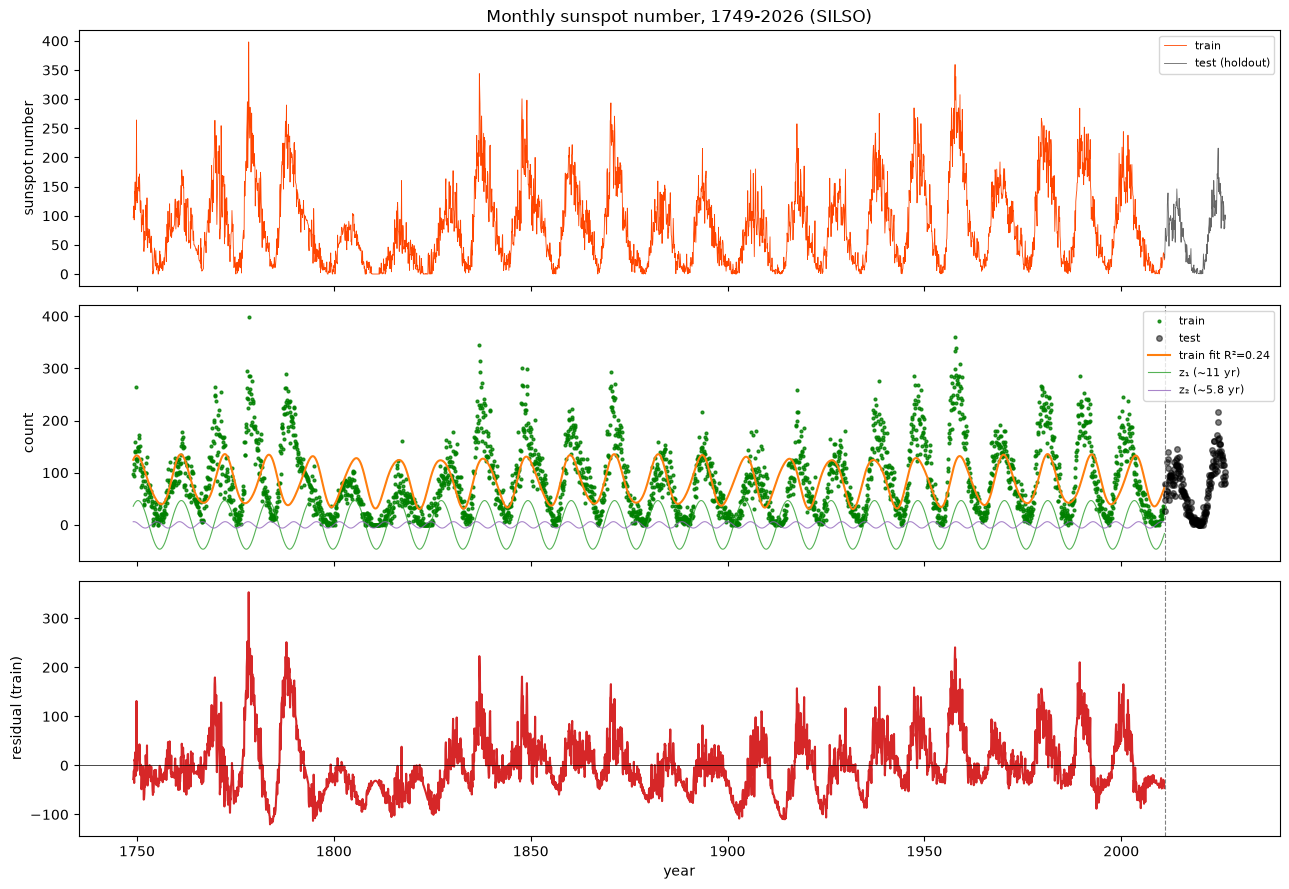

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(years_tr, counts[train_idx], "orangered", lw=0.6, label="train")
axes[0].plot(years_te, counts[test_idx], "k-", lw=0.6, alpha=0.6, label="test (holdout)")
axes[0].set_ylabel("sunspot number")
axes[0].set_title("Monthly sunspot number, 1749-2026 (SILSO)")
axes[0].legend(fontsize=8)

plot_fit_with_residual(
    axes[1:], years_tr, y_tr, fit["y_hat_log"],
    x_test=years_te, y_test=y_te,
    train_label="train", test_label="test",
    fit_label=f"train fit R²={fit['r2_log']:.2f}",
    extra_lines=[
        (years_tr, fit["component1_log"], {"color": "C2", "alpha": 0.8, "lw": 0.8, "label": f"z\u2081 (~{s1['period_years']/12:.0f} yr)"}),
        (years_tr, fit["component2_log"], {"color": "C4", "alpha": 0.8, "lw": 0.8, "label": f"z\u2082 (~{s2['period_years']/12:.1f} yr)"}),
    ],
    ylabel="count", residual_ylabel="residual (train)", xlabel="year",
    forecast_start_x=split["train_end_year"],
)
plt.tight_layout()
plt.show()


## Step 2: one shared warp for both sines

Same dual loss as before:

```
loss = λ·obj_err − (1−λ)·obj_time        (λ = 0.5)
```

`obj_err` is the Gaussian NLL of the monthly counts against the warped output function; `obj_time` is the random-walk log-likelihood on the warp offsets `p − i`. Path scale $\sigma_t$ and observation noise $\sigma_y$ both come out of the fit.


In [4]:
from warp_regression import WarpModel, soft_warp_numpy, DEFAULT_PATH_ANCHOR

z1 = prefit_res.covariates["z1"]
z2 = prefit_res.covariates["z2"]

linear = WarpModel.from_yaml(
    "sunspots_linear.yaml",
    overrides={"train": {"epochs": 1500, "fit_lambda": 0.5, "seed": 0}},
)
fit_lin = linear.fit(
    y_tr, covariates={"z1": z1[:n_train], "z2": z2[:n_train]}, sine_fit=fit,
)
fit_w = {**fit, **fit_lin.fit}
fit_w["y_hat_log"] = fit_lin.y_hat
fit_w["r2_log"] = fit_lin.r2
fit_w["rmse_log"] = fit_lin.rmse
fit_w["y_hat_log_unwarped"] = fit["y_hat_log"]
fit_w["r2_log_unwarped"] = fit["r2_log"]
p = fit_w["warp"]["p"]
fit_w["z1"] = z1[:n_train]
fit_w["z2"] = z2[:n_train]
fit_w["z1_warped"] = soft_warp_numpy(fit_w["z1"], p, path_anchor=DEFAULT_PATH_ANCHOR)
fit_w["z2_warped"] = soft_warp_numpy(fit_w["z2"], p, path_anchor=DEFAULT_PATH_ANCHOR)
B_init = linear.path_B()
w = fit_w["warp"]
print(f"Before warp (train): R2={fit_w['r2_log_unwarped']:.3f}")
print(f"After warp (train):  R2={fit_w['r2_log']:.3f}  RMSE={fit_w['rmse_log']:.1f}")
print(f"Dual LL: obj_err={w['obj_err']:.1f}  obj_time={w['obj_time']:.1f}")
print(f"Learned sigma_t={w['sigma_t']:.3f} (path), sigma_y={w['sigma_y']:.1f} (fit), max|p-i|={w['max_abs_offset']:.1f} months (~{w['max_abs_offset']/12:.1f} yr)")


Before warp (train): R2=0.237
After warp (train):  R2=0.569  RMSE=44.9
Dual LL: obj_err=16424.7  obj_time=1.1
Learned sigma_t=0.171 (path), sigma_y=45.2 (fit), max|p-i|=56.1 months (~4.7 yr)


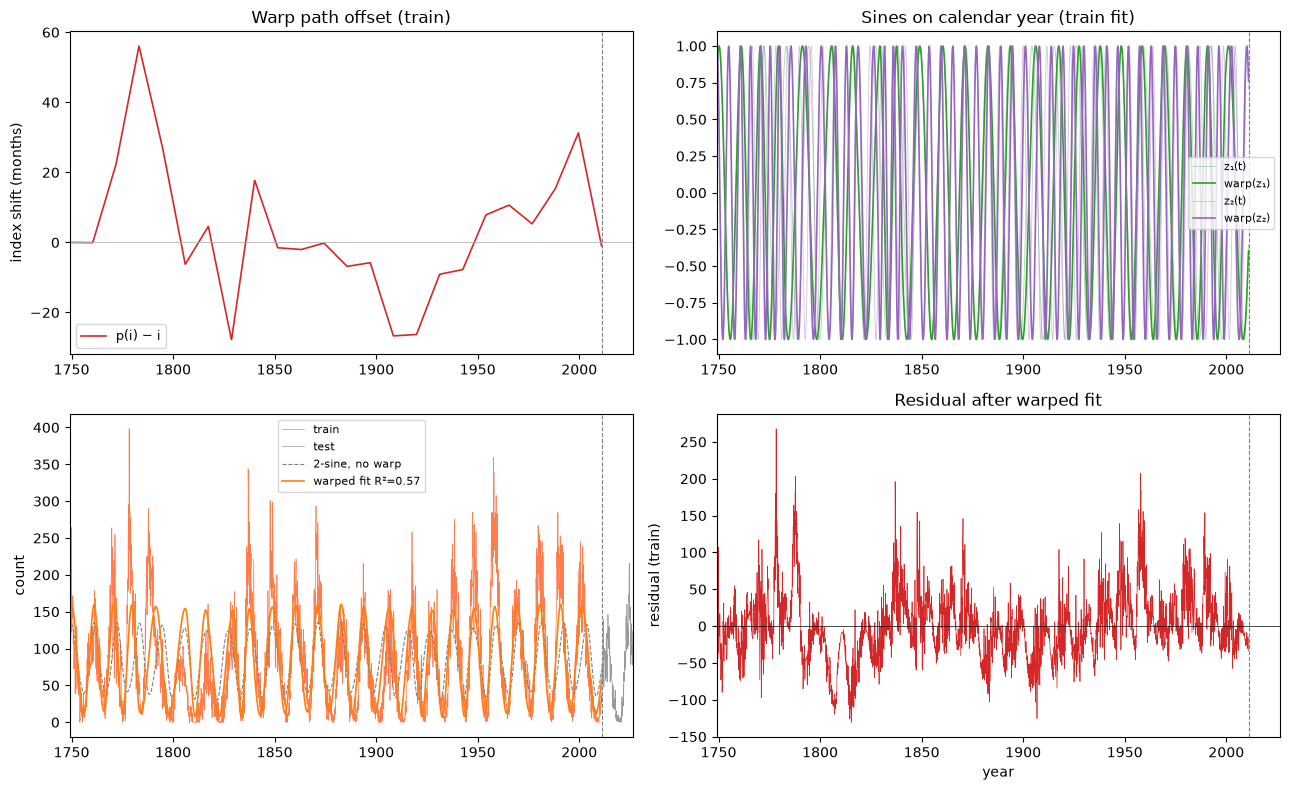

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

plot_warp_offset(axes[0, 0], years_tr, p, label="p(i) \u2212 i", title="Warp path offset (train)")
axes[0, 0].set_ylabel("index shift (months)")

axes[0, 1].plot(years_tr, fit_w["z1"], "C2", alpha=0.4, lw=0.6, label="z\u2081(t)")
axes[0, 1].plot(years_tr, fit_w["z1_warped"], "C2", lw=1.2, label="warp(z\u2081)")
axes[0, 1].plot(years_tr, fit_w["z2"], "C4", alpha=0.4, lw=0.6, label="z\u2082(t)")
axes[0, 1].plot(years_tr, fit_w["z2_warped"], "C4", lw=1.2, label="warp(z\u2082)")
axes[0, 1].set_title("Sines on calendar year (train fit)")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(years_tr, y_tr, "orangered", lw=0.5, alpha=0.7, label="train")
axes[1, 0].plot(years_te, y_te, "k-", lw=0.5, alpha=0.4, label="test")
axes[1, 0].plot(years_tr, fit_w["y_hat_log_unwarped"], "--", color="gray", lw=0.8, label="2-sine, no warp")
axes[1, 0].plot(years_tr, fit_w["y_hat_log"], "C1", lw=1.2, label=f"warped fit R\u00b2={fit_w['r2_log']:.2f}")
axes[1, 0].set_ylabel("count")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(years_tr, y_tr - fit_w["y_hat_log"], "C3", lw=0.5)
axes[1, 1].axhline(0, color="k", lw=0.5)
axes[1, 1].set_ylabel("residual (train)")
axes[1, 1].set_xlabel("year")
axes[1, 1].set_title("Residual after warped fit")

for ax in axes.ravel():
    ax.axvline(split["train_end_year"], color="gray", ls="--", lw=0.8)
    ax.set_xlim(years[0], years[-1])

plt.tight_layout()
plt.show()


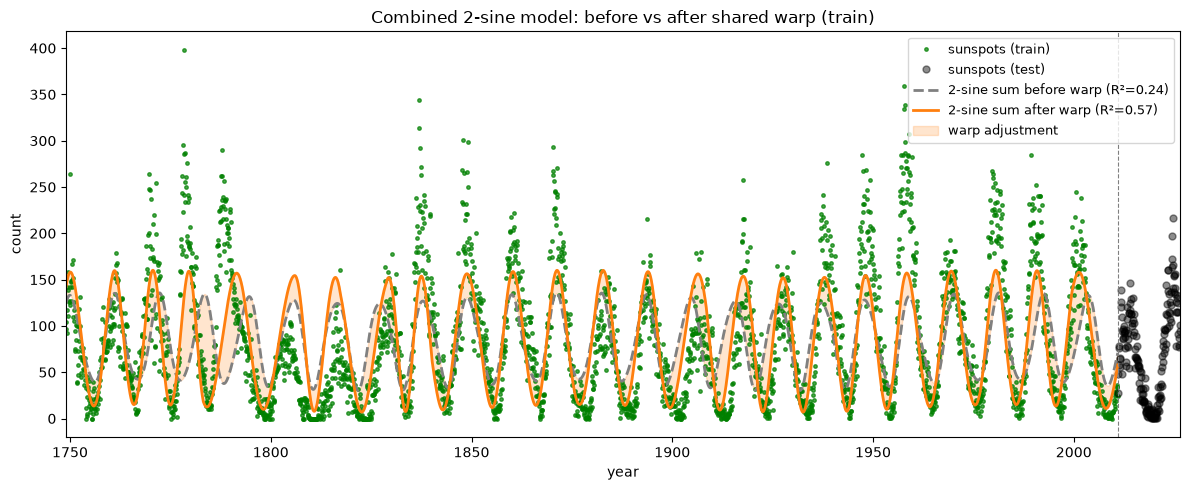

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_before_after_warp(
    ax, years_tr, y_tr, fit_w["y_hat_log_unwarped"], fit_w["y_hat_log"],
    x_test=years_te, y_test=y_te,
    r2_before=fit_w["r2_log_unwarped"], r2_after=fit_w["r2_log"],
    before_label="2-sine sum before warp", after_label="2-sine sum after warp",
    train_label="sunspots (train)", test_label="sunspots (test)",
    forecast_start_x=split["train_end_year"],
    ylabel="count", xlabel="year",
    title="Combined 2-sine model: before vs after shared warp (train)",
)
ax.set_xlim(years[0], years[-1])
plt.tight_layout()
plt.show()


## Step 3: swap in a nonlinear observation model

A straight sum of two sines is a strong assumption. We replace the linear map with small MLPs on each warped covariate ($f$ and $g$, hidden size 32).

$$\widehat{y} = f(\mathrm{warp}(z_1)) + g(\mathrm{warp}(z_2))$$

Still trained with $\lambda = 0.5$. Copy warp knots $B$ from the linear model into a **new** MLP `WarpModel` as `B_init`.


In [7]:
from warp_regression import WarpModel

model = WarpModel.from_yaml(
    "sunspots.yaml",
    overrides={"train": {"epochs": 2500, "fit_lambda": 0.5, "seed": 0}},
)
fit_res = model.fit(
    y_tr,
    covariates={"z1": z1[:n_train], "z2": z2[:n_train]},
    sine_fit=fit,
    B_init=B_init,
)
fit_nl = {**fit, **fit_res.fit}
fit_nl["y_hat_log"] = fit_res.y_hat
fit_nl["r2_log"] = fit_res.r2
fit_nl["rmse_log"] = fit_res.rmse
fit_nl["y_hat_log_linear_warp"] = fit_w["y_hat_log"]
fit_nl["r2_log_linear_warp"] = fit_w["r2_log"]
fit_nl["r2_log_unwarped"] = fit["r2_log"]
fit_nl["y_hat_log_unwarped"] = fit["y_hat_log"]
p_nl = fit_nl["warp"]["p"]
print(
    f"unwarped f+g (train): R2={fit_nl['r2_log_unwarped']:.3f}  |  "
    f"linear warp: R2={fit_nl['r2_log_linear_warp']:.3f}  |  "
    f"f(warp)+g(warp): R2={fit_nl['r2_log']:.3f}"
)
print(f"Dual LL: obj_err={fit_nl['warp']['obj_err']:.1f}  obj_time={fit_nl['warp']['obj_time']:.1f}")
print(f"sigma_y={fit_nl['warp']['sigma_y']:.1f}  max |p-i| ~ {fit_nl['warp']['max_abs_offset']:.1f} months (~{fit_nl['warp']['max_abs_offset']/12:.1f} yr)")

# Cycle contributions from the MLP observation model
import torch
from warp_regression import soft_warp_numpy, DEFAULT_PATH_ANCHOR
z1w = soft_warp_numpy(z1[:n_train], p_nl, path_anchor=DEFAULT_PATH_ANCHOR)
z2w = soft_warp_numpy(z2[:n_train], p_nl, path_anchor=DEFAULT_PATH_ANCHOR)
obs = model.observation
with torch.no_grad():
    z1_t = torch.tensor(z1w, dtype=torch.float32)
    z2_t = torch.tensor(z2w, dtype=torch.float32)
    mlps = list(obs.mlps.values())
    fit_nl["component1_log"] = mlps[0](z1_t).numpy()
    fit_nl["component2_log"] = mlps[1](z2_t).numpy()


unwarped f+g (train): R2=0.237  |  linear warp: R2=0.569  |  f(warp)+g(warp): R2=0.614
Dual LL: obj_err=16249.7  obj_time=0.8
sigma_y=42.5  max |p-i| ~ 64.9 months (~5.4 yr)


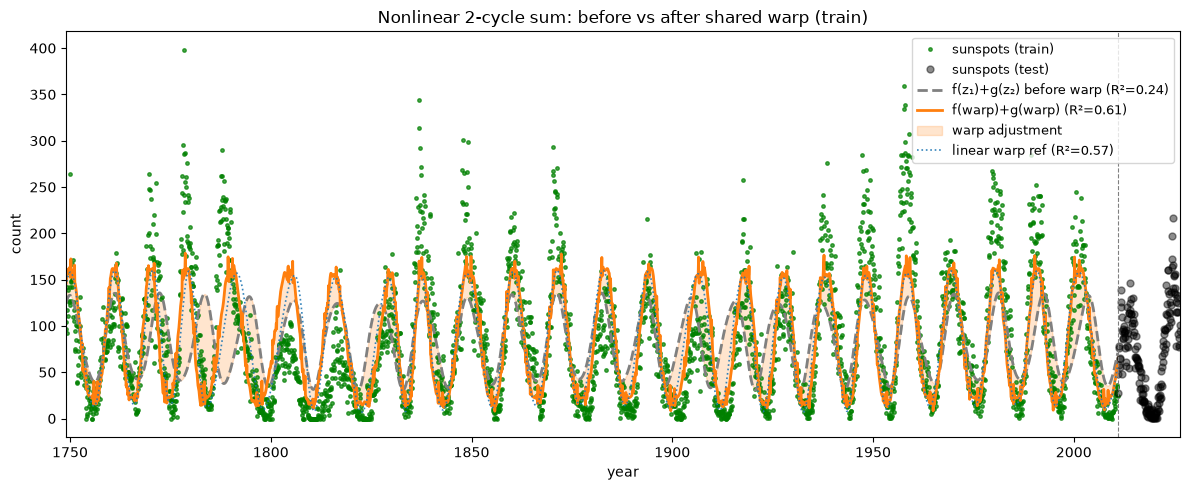

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_before_after_warp(
    ax, years_tr, y_tr, fit_nl["y_hat_log_unwarped"], fit_nl["y_hat_log"],
    x_test=years_te, y_test=y_te,
    r2_before=fit_nl["r2_log_unwarped"], r2_after=fit_nl["r2_log"],
    before_label="f(z\u2081)+g(z\u2082) before warp", after_label="f(warp)+g(warp)",
    train_label="sunspots (train)", test_label="sunspots (test)",
    extra_lines=[(years_tr, fit_nl["y_hat_log_linear_warp"], {"color": "C0", "ls": ":", "lw": 1.2, "alpha": 0.9, "label": f"linear warp ref (R\u00b2={fit_nl['r2_log_linear_warp']:.2f})"})],
    forecast_start_x=split["train_end_year"],
    ylabel="count", xlabel="year",
    title="Nonlinear 2-cycle sum: before vs after shared warp (train)",
)
ax.set_xlim(years[0], years[-1])
plt.tight_layout()
plt.show()


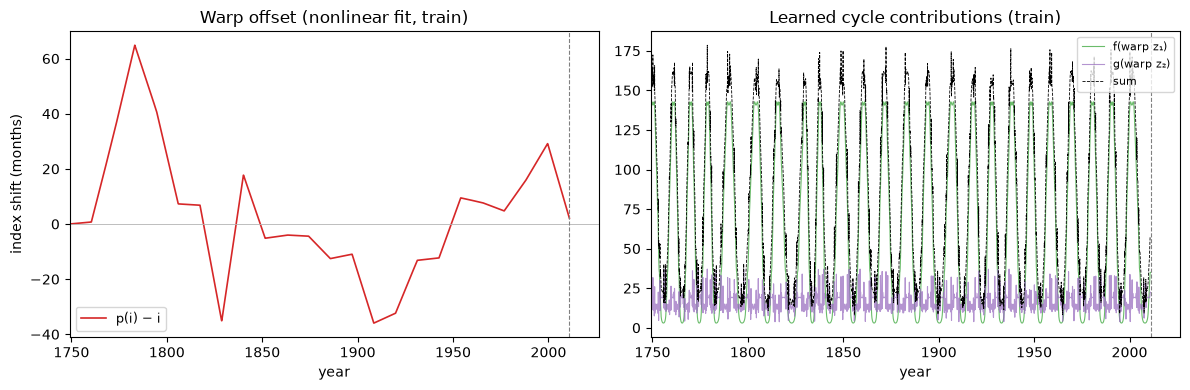

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_warp_offset(axes[0], years_tr, p_nl, label="p(i) \u2212 i", title="Warp offset (nonlinear fit, train)")
axes[0].set_ylabel("index shift (months)")
axes[1].plot(years_tr, fit_nl["component1_log"], "C2", alpha=0.7, lw=0.8, label="f(warp z\u2081)")
axes[1].plot(years_tr, fit_nl["component2_log"], "C4", alpha=0.7, lw=0.8, label="g(warp z\u2082)")
axes[1].plot(years_tr, fit_nl["y_hat_log"], "k--", lw=0.6, label="sum")
axes[1].set_title("Learned cycle contributions (train)")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.axvline(split["train_end_year"], color="gray", ls="--", lw=0.8)
    ax.set_xlim(years[0], years[-1])
    ax.set_xlabel("year")
plt.tight_layout()
plt.show()


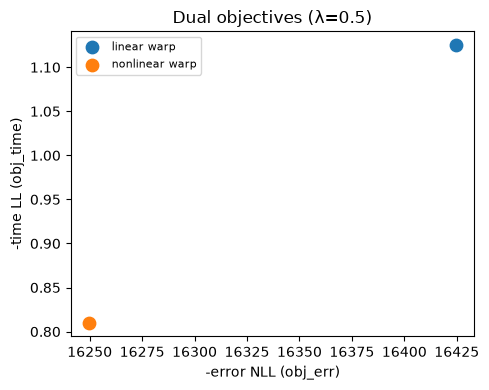

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_dual_objective_scatter(
    ax,
    [
        {"x": fit_w["warp"]["obj_err"], "y": fit_w["warp"]["obj_time"], "label": "linear warp"},
        {"x": fit_nl["warp"]["obj_err"], "y": fit_nl["warp"]["obj_time"], "label": "nonlinear warp"},
    ],
    title="Dual objectives (\u03bb=0.5)",
)
plt.tight_layout()
plt.show()


## Step 4: forecast the years we held out

Sample from the **fitted** start-pinned path (no prepare/refit). Early train knots stay at the MAP; the last train knot gets a terror-scale kick, then the usual knot RW continues into the holdout. Two percentile bands at coverage `ci` (default 95%): **time-warp** and **total** (warp + iid $e_t$), with actual holdout coverage reported against the nominal level — same API as Lynx / WarpDifferentiable.


In [11]:
from warp_regression import (
    as_forecast_state,
    build_dual_sines_from_fit,
    forecast_from_state,
)

ci = 0.95
z1, z2 = build_dual_sines_from_fit(t, fit)
fit_nl["_y_log_train"] = y_tr
fit_nl["_y_log_test"] = y_te
fit_nl["warp"]["n_knots"] = 24
n_knots = 24

state = as_forecast_state(fit_nl, z1_full=z1, z2_full=z2, n_train=n_train)
fc = forecast_from_state(
    state, n_future=split["n_test"], n_draws=500, n_paths_ci=500,
    seed=43, noise_seed=2, ci=ci,
)
bands = fc["bands"]
y_point = fc["y_point"]
fc["corr_log_train"] = float(np.corrcoef(y_point[train_idx], y_tr)[0, 1])
fc["corr_log_test"] = float(np.corrcoef(y_point[test_idx], y_te)[0, 1])
fc["rmse_log_test"] = float(np.sqrt(np.mean((y_point[test_idx] - y_te) ** 2)))
fc["coverage_total"] = interval_coverage(y_te, bands["c_q_lo"][test_idx], bands["c_q_hi"][test_idx])
fc["coverage_warp"] = interval_coverage(y_te, bands["t_q_lo"][test_idx], bands["t_q_hi"][test_idx])
fc["coverage_combined_95_test"] = fc["coverage_total"]

print(f"terminal_offset={fc.get('terminal_offset', float('nan')):.3f}  (start-pinned fit path)")
print(f"Train {int(years_tr[0])}-{int(years_tr[-1])} (n={n_train})")
print(f"Test  {int(years_te[0])}-{int(years_te[-1])} (n={split['n_test']})")
print(f"In-sample fit R2 (train, point path) = {fit_nl['r2_log']:.3f}")
print(f"Point forecast train/test corr = {fc['corr_log_train']:.3f} / {fc['corr_log_test']:.3f}")
print(f"Test RMSE (point) = {fc['rmse_log_test']:.1f}")
print(
    f"sigma_t={fc['sigma_t']:.3f}  sigma_y={fc['sigma_y']:.1f}  "
    f"sigma_index={per_index_rw_sigma(fc['sigma_t'], n_train, n_knots):.3f}"
)
print(
    f"CI nominal={ci:.0%}  |  actual total={fc['coverage_total']:.1%}  "
    f"|  actual warp={fc['coverage_warp']:.1%}"
)


terminal_offset=2.118  (start-pinned fit path)
Train 1749-2010 (n=3144)
Test  2011-2026 (n=186)
In-sample fit R2 (train, point path) = 0.614
Point forecast train/test corr = 0.784 / 0.839
Test RMSE (point) = 39.9
sigma_t=0.171  sigma_y=42.5  sigma_index=2.005
CI nominal=95%  |  actual total=100.0%  |  actual warp=71.5%


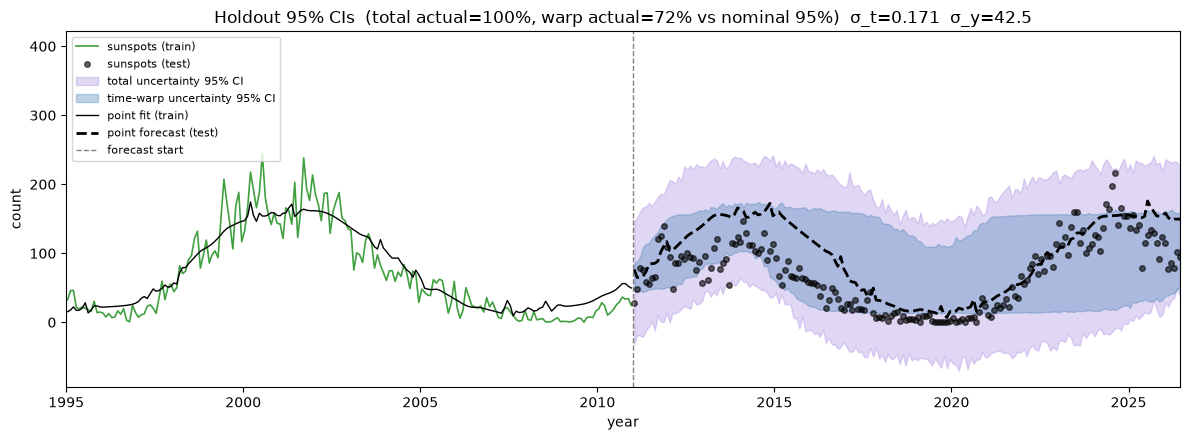

warp  band width at test start/end: 40 / 106
total band width at test start/end: 178 / 190


In [12]:
train_end = split["train_end_year"]
y_point = fc["y_point"]
sigma_y = fc["sigma_y"]
yt = years[test_idx]
ci_pct = int(round(100 * ci))
bands_test = {k: bands[k][test_idx] for k in ("t_q_lo", "t_q_hi", "c_q_lo", "c_q_hi")}
bands_test["ci"] = ci

fig, ax = plt.subplots(figsize=(12, 4.5))
plot_forecast_bands(
    ax, years_tr, y_tr, yt, bands_test,
    x_test=yt, y_test=y_te,
    point_lines=[
        (years_tr, y_point[train_idx], {"color": "black", "lw": 1, "label": "point fit (train)"}),
        (yt, y_point[test_idx], {"color": "black", "lw": 2, "ls": "--", "label": "point forecast (test)"}),
    ],
    forecast_start_x=train_end,
    train_label="sunspots (train)", test_label="sunspots (test)",
    xlabel="year", ylabel="count",
    title=(
        f"Holdout {ci_pct}% CIs  (total actual={fc['coverage_total']:.0%}, "
        f"warp actual={fc['coverage_warp']:.0%} vs nominal {ci_pct}%)  "
        f"σ_t={fc['sigma_t']:.3f}  σ_y={sigma_y:.1f}"
    ),
)
ax.set_xlim(1995, years[-1])
fig.tight_layout()
plt.show()

f0, f1 = test_idx[0], test_idx[-1]
print(f"warp  band width at test start/end: {(bands['t_q_hi'][f0]-bands['t_q_lo'][f0]):.0f} / {(bands['t_q_hi'][f1]-bands['t_q_lo'][f1]):.0f}")
print(f"total band width at test start/end: {(bands['c_q_hi'][f0]-bands['c_q_lo'][f0]):.0f} / {(bands['c_q_hi'][f1]-bands['c_q_lo'][f1]):.0f}")


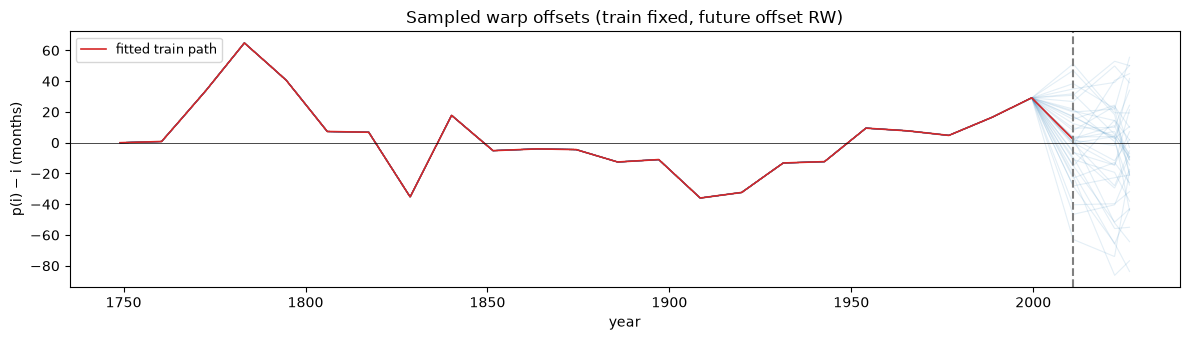

In [13]:
# What do the sampled future warp offsets actually look like against the fitted train path?
paths_p = fc["paths_p"]
idx = np.arange(len(years))
fig, ax = plt.subplots(figsize=(12, 3.5))
for k in range(min(40, len(paths_p))):
    ax.plot(years, paths_p[k] - idx, color="C0", alpha=0.12, lw=0.8)
ax.plot(years_tr, fit_nl["warp"]["p"] - idx[:n_train], "C3", lw=1.2, label="fitted train path")
ax.axvline(train_end, color="gray", ls="--")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("p(i) \u2212 i (months)")
ax.set_xlabel("year")
ax.set_title("Sampled warp offsets (train fixed, future offset RW)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Step 5: how long until the next solar maximum?

Same question as Lynx's cycle-length step: not "how high", but "when". Extend warp paths forward with the fitted $\sigma_t$ and measure the peak-to-peak spacing on the slow ~11-year component $z_1$. Because the data is monthly, `analyze_cycle_lengths` naturally measures lengths in months; we convert to years for the plot below.


Nominal cycle ≈ 11.0 yr  |  sample median = 13.0 yr  |  σ_t = 0.171


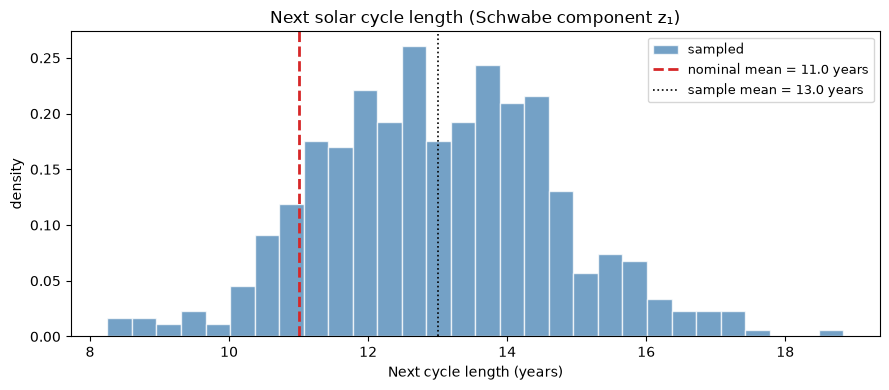

In [14]:
from dataclasses import replace

from warp_regression import analyze_cycle_lengths, plot_cycle_length_distribution

cyc = analyze_cycle_lengths(
    fit=fit_nl,
    n_calendar=n_train,
    unit="months",
    n_paths=500,
    seed=7,
)
cyc_years = replace(
    cyc,
    lengths=cyc.lengths / 12.0,
    mean_cycle_length=cyc.mean_cycle_length / 12.0,
    unit="years",
)

fig, ax = plt.subplots(figsize=(9, 4))
plot_cycle_length_distribution(cyc_years, ax=ax, title="Next solar cycle length (Schwabe component z\u2081)")
print(
    f"Nominal cycle \u2248 {cyc_years.mean_cycle_length:.1f} yr  |  "
    f"sample median = {np.median(cyc_years.lengths):.1f} yr  |  "
    f"\u03c3_t = {cyc_years.sigma_t:.3f}"
)
fig.tight_layout()
plt.show()


## Step 6: how does this compare to a classical structural time series model?

Same baseline as Lynx: Harvey's structural time series model, a level plus a stochastic damped cycle plus irregular noise, fit via Kalman filter. `statsmodels`'s `UnobservedComponents` only supports a single cycle frequency, which is actually a fairer fight here than it was for Lynx: the Schwabe cycle really is the one dominant periodicity in this series, there's no second cycle competing for that one frequency slot the way Lynx's ~4-year wobble was.


In [15]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

counts_tr, counts_te = counts[train_idx], counts[test_idx]
y_hat_tr, y_hat_te = y_point[train_idx], y_point[test_idx]
in_combined = (counts_te >= bands_test["c_q_lo"]) & (counts_te <= bands_test["c_q_hi"])

# Same reasoning as Lynx: UnobservedComponents is a linear Gaussian model, so it
# still needs a log1p transform to behave on this right-skewed series, even
# though the warp model's nonlinear observation model don't need one.
y_log_tr = np.log1p(counts_tr)


def fit_harvey_ucm(stochastic_level: bool):
    m = UnobservedComponents(
        y_log_tr, level=True, stochastic_level=stochastic_level,
        cycle=True, stochastic_cycle=True, damped_cycle=True, irregular=True,
    )
    r = m.fit(disp=False, maxiter=500)
    freq = r.params[[i for i, n in enumerate(r.param_names) if "frequency" in n][0]]
    period_yr = (2 * np.pi / freq) / 12.0
    fcst = r.get_forecast(steps=split["n_test"])
    mean_log = fcst.predicted_mean
    lo_log, hi_log = fcst.conf_int(alpha=0.05).T
    mean_c, lo_c, hi_c = np.expm1(mean_log), np.expm1(lo_log), np.expm1(hi_log)
    return {
        "res": r, "period_yr": period_yr, "mean_c": mean_c, "lo_c": lo_c, "hi_c": hi_c,
        "rmse_c": float(np.sqrt(np.mean((mean_c - counts_te) ** 2))),
        "cov_c": float(np.mean((counts_te >= lo_c) & (counts_te <= hi_c))),
        "width_c": float(np.mean(hi_c - lo_c)),
    }


ucm_fixed = fit_harvey_ucm(stochastic_level=False)
ucm_rw = fit_harvey_ucm(stochastic_level=True)

warp_rmse_c = float(np.sqrt(np.mean((y_hat_te - counts_te) ** 2)))
warp_cov_c = float(in_combined.mean())
warp_width_c = float(np.mean(bands_test["c_q_hi"] - bands_test["c_q_lo"]))

rows = [
    ("warp regression (2 cycles)", None, warp_rmse_c, warp_cov_c, warp_width_c),
    ("Harvey UCM, fixed level", ucm_fixed["period_yr"], ucm_fixed["rmse_c"], ucm_fixed["cov_c"], ucm_fixed["width_c"]),
    ("Harvey UCM, random-walk level", ucm_rw["period_yr"], ucm_rw["rmse_c"], ucm_rw["cov_c"], ucm_rw["width_c"]),
]
print(f"{'model':30s} {'period(yr)':>10s} {'RMSE(count)':>11s} {'cov95':>7s} {'width(count)':>12s}")
for name, period, rmse_c, cov, width in rows:
    period_s = f"{period:.1f}" if period is not None else "n/a"
    print(f"{name:30s} {period_s:>10s} {rmse_c:>11.0f} {cov*100:>6.0f}% {width:>12.0f}")


model                          period(yr) RMSE(count)   cov95 width(count)
warp regression (2 cycles)            n/a          40    100%          214
Harvey UCM, fixed level              12.4          49     92%          645
Harvey UCM, random-walk level         0.4          65    100%         3884


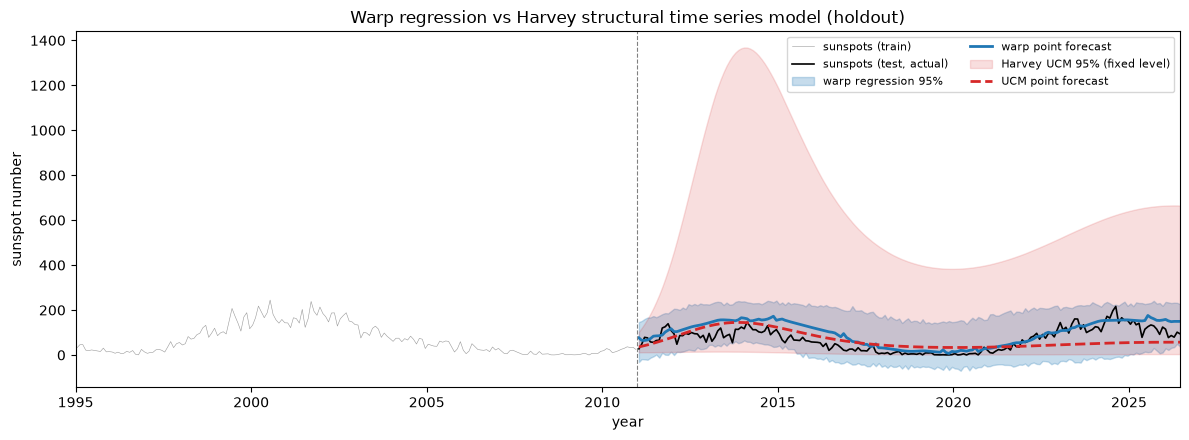

In [16]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(years_tr, counts_tr, "-", lw=0.4, color="0.6", label="sunspots (train)")
ax.plot(yt, counts_te, "k-", lw=1.2, label="sunspots (test, actual)")
ax.fill_between(yt, bands_test["c_q_lo"], bands_test["c_q_hi"], color="C0", alpha=0.25, label="warp regression 95%")
ax.plot(yt, y_hat_te, color="C0", lw=2, label="warp point forecast")
ax.fill_between(yt, ucm_fixed["lo_c"], ucm_fixed["hi_c"], color="C3", alpha=0.15, label="Harvey UCM 95% (fixed level)")
ax.plot(yt, ucm_fixed["mean_c"], color="C3", lw=2, ls="--", label="UCM point forecast")
ax.axvline(train_end, color="gray", ls="--", lw=0.8)
ax.set_xlim(1995, years[-1])
ax.set_ylabel("sunspot number")
ax.set_xlabel("year")
ax.set_title("Warp regression vs Harvey structural time series model (holdout)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## Wrapping up

| Step | What happened |
|------|----------------|
| 1 | Loaded 277 years of monthly sunspot counts (no log transform), prefit two calendar-time sines |
| 2 | Fit one shared warp path across both sines (λ=0.5) |
| 3 | Swapped in nonlinear MLP observation models, path knots copied from the linear model |
| 4 | Forecast 2011-2026 in counts directly, with terror + combined 95% bands |
| 5 | Distribution over the next solar cycle's length, not just its height |
| 6 | Compared against Harvey's structural time series model |

The Schwabe cycle is a genuinely hard forecasting target: solar physicists still disagree on how far ahead cycle amplitude and timing can be predicted, and a purely calendar-fixed sine pair gets nowhere close (see the unwarped-vs-warped R² above). Warp regression's holdout coverage and the Harvey UCM comparison numbers are printed above too; on this series the single-cycle classical baseline is a closer fight than it was for Lynx, since sunspots really only have the one dominant periodicity that `UnobservedComponents` is built to track.

That rounds out the notebook set: [WarpDifferentiable](WarpDifferentiable.ipynb) for the mechanics on synthetic data, [Lynx](LynxForecast.ipynb) and [Bitcoin](BitcoinWarp.ipynb) for real cycles with multiple components or a dominant trend, and this one for the longest, noisiest series of the four.
